# Precedent — faithfulness experiment (Kaggle, run 2)

The first notebook explained **one** order. This one repeats the test on many orders and adds the fixes from that run.

**What changed**

- Data cleaning: blank payment-term codes are removed, and ID/index columns are no longer used as features.
- Rows come from a random sample of the whole SALT training split, not its first 200,000 rows.
- Orders to explain are picked at random, not by confidence.
- A harder comparison is added: removing the 10 **most similar** rows (plain nearest neighbours), next to removing 10 random rows.
- Results are saved after every order, so you can stop and resume.

**Runtime.** Each order needs about 190 small model calls. `MAX_HOURS` stops the loop cleanly when the time budget is used up. To run it unattended, use **Save Version → Save & Run All (Commit)**.

Same setup as before: GPU T4, Internet on, secrets `TABPFN_TOKEN` and `HF_TOKEN` attached.

In [1]:
!pip install -q -U tabpfn datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 22.3 MB/s eta 0:00:00


In [2]:
import os, time, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

def get_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        return os.environ.get(name)

TABPFN_TOKEN, HF_TOKEN = get_secret("TABPFN_TOKEN"), get_secret("HF_TOKEN")
assert TABPFN_TOKEN, "Attach the TABPFN_TOKEN secret to this notebook."
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
os.environ["TABPFN_NO_BROWSER"] = "1"
if HF_TOKEN: os.environ["HF_TOKEN"] = HF_TOKEN

import torch, tabpfn
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion
print("tabpfn", tabpfn.__version__, "| GPU:", torch.cuda.is_available())

def make_model(fast=True, **overrides):
    version = ModelVersion.V3_5_FAST if fast else ModelVersion.V3_5
    return TabPFNClassifier.create_default_for_version(version, **overrides)

tabpfn 9.1.0 | GPU: True


## 1. Settings

In [3]:
TARGET       = "CUSTOMERPAYMENTTERMS"
N_CONTEXT    = 2000     # solved examples the model may look at
N_TEST       = 1000     # orders used for the accuracy comparison
N_EXPLAIN    = 100      # orders that get the full explain + removal test
K            = 60       # nearest context rows used as the local context
M            = 180      # random half-subsets per order (3 x K)
TOP_K        = 10       # rows removed in each removal test
N_RANDOM     = 5        # random-removal repeats per order
N_FRESH      = 20       # fresh subsets for the surrogate check
N_EST        = 1        # TabPFN ensemble members inside the loop (1 = fastest)
MAX_HOURS    = 3.0      # time budget for the loop
SEED         = 0
RESULTS_CSV  = "precedent_results.csv"

SALT_TARGETS = ["SALESOFFICE", "SALESGROUP", "CUSTOMERPAYMENTTERMS", "SHIPPINGCONDITION",
                "PLANT", "SHIPPINGPOINT", "HEADERINCOTERMSCLASSIFICATION", "ITEMINCOTERMSCLASSIFICATION"]
ID_COLUMNS   = ["SALESDOCUMENT", "SALESDOCUMENTITEM"]   # identifiers, not business features
CUSTOMER_COL = "SOLDTOPARTY"
SAMPLE_ROWS  = 300_000

## 2. Load and clean SALT

In [4]:
def load_frame():
    from datasets import load_dataset
    ds = load_dataset("SAP/SALT", "joined_table", split="train", token=HF_TOKEN)
    return ds.to_pandas()

df = load_frame()
print("Loaded:", df.shape)
df = df.sample(n=min(SAMPLE_ROWS, len(df)), random_state=SEED)

def is_text(col):
    t = col.dtype
    return (pd.api.types.is_object_dtype(t) or pd.api.types.is_string_dtype(t)
            or isinstance(t, pd.CategoricalDtype))

# clean the target: drop missing and blank codes
df[TARGET] = df[TARGET].astype(object)
df = df[df[TARGET].notna()]
df[TARGET] = df[TARGET].astype(str).str.strip()
n_before = len(df)
df = df[df[TARGET] != ""]
print(f"Removed {n_before - len(df)} rows with a blank target")

# drop the other SALT targets (leakage), identifiers, and leftover index columns
drop = [c for c in df.columns if (c in SALT_TARGETS and c != TARGET) or c in ID_COLUMNS or c.startswith("__")]
df = df.drop(columns=drop)
print("Dropped columns:", drop)

top = df[TARGET].value_counts().index[:10]
df = df[df[TARGET].isin(top)]
print(df[TARGET].value_counts(normalize=True).round(3))

README.md:   0%|          | 0.00/6.70k [00:00<?, ?B/s]

JoinedTables_train.parquet: reconstructing file:   0%|          |  0.00B / 42.8MB            

JoinedTables_train.parquet: downloading bytes:           |  0.00B            

JoinedTables_test.parquet: reconstructing file:   0%|          |  0.00B / 9.19MB            

JoinedTables_test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1916685 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/402855 [00:00<?, ? examples/s]

Loaded: (1916685, 29)
Removed 3426 rows with a blank target
Dropped columns: ['SALESDOCUMENT', 'SALESOFFICE', 'SALESGROUP', 'SHIPPINGCONDITION', 'HEADERINCOTERMSCLASSIFICATION', 'SALESDOCUMENTITEM', 'PLANT', 'SHIPPINGPOINT', 'ITEMINCOTERMSCLASSIFICATION', '__index_level_0__']
CUSTOMERPAYMENTTERMS
32    0.297
03    0.239
54    0.149
33    0.107
00    0.067
95    0.036
42    0.030
01    0.028
96    0.026
70    0.020
Name: proportion, dtype: float64


## 3. Build the task (time-based split)

In [5]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
rng = np.random.default_rng(SEED)

date_col = next((c for c in df.columns if "DATE" in c.upper()), None)
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values(date_col)
else:
    df = df.sample(frac=1.0, random_state=SEED)
cut = int(len(df) * 0.8)
past, future = df.iloc[:cut], df.iloc[cut:]
print("Split on:", date_col or "random", "| past:", len(past), "| future:", len(future))

ctx = past.sample(n=min(N_CONTEXT, len(past)), random_state=SEED)
tst = future[future[TARGET].isin(ctx[TARGET].unique())]
tst = tst.sample(n=min(N_TEST, len(tst)), random_state=SEED)

feat = [c for c in df.columns if c != TARGET]
dropped = []
for c in list(feat):
    nun = ctx[c].nunique(dropna=True)
    if nun <= 1 or (is_text(ctx[c]) and nun > 0.95 * len(ctx)):
        feat.remove(c); dropped.append(c)
print("Dropped (constant or all-unique):", dropped)
print("Features used:", feat)

def prep(frame):
    out = frame[feat].copy()
    for c in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[c]):
            out[c] = (out[c] - pd.Timestamp("1970-01-01")).dt.days
        elif is_text(out[c]):
            out[c] = out[c].astype(object).where(out[c].notna(), "missing").astype(str).astype(object)
    return out.reset_index(drop=True)

X_ctx, X_tst = prep(ctx), prep(tst)
y_ctx, y_tst = ctx[TARGET].to_numpy(), tst[TARGET].to_numpy()

cat_cols = [c for c in feat if is_text(X_ctx[c])]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
E_ctx, E_tst = X_ctx.copy(), X_tst.copy()
if cat_cols:
    E_ctx[cat_cols] = enc.fit_transform(X_ctx[cat_cols])
    E_tst[cat_cols] = enc.transform(X_tst[cat_cols])
E_ctx = E_ctx.astype(float).fillna(-1); E_tst = E_tst.astype(float).fillna(-1)
print("Context:", X_ctx.shape, "| Test:", X_tst.shape, "| Classes:", len(np.unique(y_ctx)))

Split on: CREATIONDATE | past: 193956 | future: 48490
Dropped (constant or all-unique): ['ORGANIZATIONDIVISION']
Features used: ['SALESDOCUMENTTYPE', 'SALESORGANIZATION', 'DISTRIBUTIONCHANNEL', 'BILLINGCOMPANYCODE', 'TRANSACTIONCURRENCY', 'CREATIONDATE', 'CREATIONTIME', 'SALESDOCUMENTITEMCATEGORY', 'PRODUCT', 'SOLDTOPARTY', 'SHIPTOPARTY', 'BILLTOPARTY', 'PAYERPARTY', 'ADDRESSID_SOLDTOPARTY', 'ADDRESSID_BILLTOPARTY', 'ADDRESSID_PAYERPARTY', 'ADDRESSID_SHIPTOPARTY']
Context: (2000, 17) | Test: (1000, 17) | Classes: 10


## 4. Accuracy comparison

LightGBM here is untuned and sees ordinal-encoded categories, so read the gap as a rough indication only.

In [6]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=SEED).fit(E_ctx, y_ctx)
acc_lgbm = accuracy_score(y_tst, lgbm.predict(E_tst))

full_model = make_model(fast=True).fit(X_ctx, y_ctx)
proba_full = full_model.predict_proba(X_tst)
pred_full = full_model.classes_[proba_full.argmax(1)]
conf_full = proba_full.max(1)
acc_tab = accuracy_score(y_tst, pred_full)
majority = pd.Series(y_ctx).value_counts(normalize=True).iloc[0]

baseline = {"n_test": int(len(y_tst)), "majority_class_share": round(float(majority), 4),
            "lightgbm_acc": round(float(acc_lgbm), 4), "tabpfn35_fast_acc": round(float(acc_tab), 4)}
print(baseline)

tabpfn-v3.5-fast-20260909.safetensors: reconstructing file:   0%|          |  0.00B /  334MB            

tabpfn-v3.5-fast-20260909.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

{'n_test': 1000, 'majority_class_share': 0.3125, 'lightgbm_acc': 0.415, 'tabpfn35_fast_acc': 0.644}


## 5. Explain + removal test for many orders

For each order:

1. take its `K` nearest context rows (the local context);
2. re-predict on `M` random half-subsets and fit a ridge regression, giving one influence score per row;
3. remove the top-10 **precedents** and re-predict;
4. remove the 10 **nearest** rows and re-predict (similarity baseline);
5. remove 10 **random** rows, `N_RANDOM` times;
6. check the surrogate on `N_FRESH` unseen subsets (Spearman correlation).

An explanation counts as **verified** when removing the precedents lowers the predicted probability by at least 0.05 and by more than every random removal.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

scaler = StandardScaler().fit(E_ctx)
nn = NearestNeighbors(n_neighbors=min(K, len(E_ctx))).fit(scaler.transform(E_ctx))
has_customer = CUSTOMER_COL in X_ctx.columns

def predict_with(rows, x_row):
    # Returns {class: probability} for x_row, using only these context rows
    ys_ = y_ctx[rows]
    classes = np.unique(ys_)
    if len(classes) == 1:
        return {classes[0]: 1.0}
    m = make_model(fast=True, n_estimators=N_EST).fit(X_ctx.iloc[rows], ys_)
    return dict(zip(m.classes_, m.predict_proba(x_row)[0].astype(float)))

def explain_row(i, row_rng):
    x_row = X_tst.iloc[[i]]
    local = nn.kneighbors(scaler.transform(E_tst.iloc[[i]]), return_distance=False)[0]   # sorted nearest-first
    k = len(local)
    base = predict_with(local, x_row)
    target = max(base, key=base.get)
    p_local = base[target]
    p_of = lambda rows: predict_with(rows, x_row)

    def masks_(n):
        mk = np.zeros((n, k), dtype=bool)
        for r in range(n):
            mk[r, row_rng.choice(k, size=k // 2, replace=False)] = True
        return mk

    masks = masks_(M)
    outs = np.array([p_of(local[mk]).get(target, 0.0) for mk in masks])
    surrogate = Ridge(alpha=1.0).fit(masks.astype(float), outs)
    order = np.argsort(-surrogate.coef_)
    top = order[:TOP_K]

    def removal(drop_positions):
        keep = np.ones(k, dtype=bool); keep[drop_positions] = False
        res = p_of(local[keep])
        return p_local - res.get(target, 0.0), max(res, key=res.get) != target

    drop_prec, flip_prec = removal(top)
    drop_near, flip_near = removal(np.arange(TOP_K))
    rand = [removal(row_rng.choice(k, size=TOP_K, replace=False)) for _ in range(N_RANDOM)]
    drops_rand = np.array([d for d, _ in rand])

    fresh = masks_(N_FRESH)
    actual = np.array([p_of(local[mk]).get(target, 0.0) for mk in fresh])
    lds = spearmanr(surrogate.predict(fresh.astype(float)), actual).correlation if actual.std() > 0 else np.nan

    prec_rows = local[top]
    same_cust = (int((X_ctx.iloc[prec_rows][CUSTOMER_COL].to_numpy() == x_row[CUSTOMER_COL].iloc[0]).sum())
                 if has_customer else -1)
    return {
        "test_row": int(i), "true_label": y_tst[i], "pred_local": target, "correct": bool(target == y_tst[i]),
        "p_full": float(conf_full[i]), "pred_full": pred_full[i], "p_local": float(p_local),
        "drop_precedents": float(drop_prec), "drop_nearest": float(drop_near),
        "drop_random_mean": float(drops_rand.mean()), "drop_random_max": float(drops_rand.max()),
        "flip_precedents": bool(flip_prec), "flip_nearest": bool(flip_near),
        "flip_random_share": float(np.mean([f for _, f in rand])),
        "verified": bool(drop_prec >= 0.05 and drop_prec > drops_rand.max()),
        "surrogate_spearman": float(lds), "output_std": float(outs.std()),
        "top_coef": float(surrogate.coef_[top[0]]), "coef_share_top2": float(
            np.clip(surrogate.coef_[top[:2]], 0, None).sum() / max(np.clip(surrogate.coef_, 0, None).sum(), 1e-9)),
        "precedents_same_label": int((y_ctx[prec_rows] == target).sum()),
        "precedents_same_customer": same_cust,
        "overlap_prec_nearest": int(len(set(top.tolist()) & set(range(TOP_K)))),
        "precedent_context_rows": json.dumps([int(r) for r in prec_rows]),
    }

explain_ids = np.random.default_rng(SEED).choice(len(X_tst), size=min(N_EXPLAIN, len(X_tst)), replace=False)
LABEL_COLS = {"true_label": str, "pred_local": str, "pred_full": str}
done = pd.read_csv(RESULTS_CSV, dtype=LABEL_COLS) if os.path.exists(RESULTS_CSV) else pd.DataFrame()
done_ids = set(done["test_row"].tolist()) if len(done) else set()
rows, t_start = done.to_dict("records"), time.time()
print(f"Resuming with {len(done_ids)} orders already done" if done_ids else "Starting fresh")

for n, i in enumerate(explain_ids):
    if int(i) in done_ids:
        continue
    if (time.time() - t_start) / 3600 > MAX_HOURS:
        print("Time budget reached; stopping cleanly."); break
    t0 = time.time()
    rows.append(explain_row(int(i), np.random.default_rng(SEED + int(i))))
    pd.DataFrame(rows).to_csv(RESULTS_CSV, index=False)
    if len(rows) <= 3 or len(rows) % 10 == 0:
        per = time.time() - t0
        left = len(explain_ids) - n - 1
        print(f"{len(rows)} done | {per:.0f}s per order | about {per * left / 60:.0f} min left")

res = pd.DataFrame(rows)
print("Orders explained:", len(res))

Starting fresh
1 done | 88s per order | about 145 min left
2 done | 87s per order | about 142 min left
3 done | 86s per order | about 140 min left
10 done | 86s per order | about 130 min left
20 done | 86s per order | about 115 min left
30 done | 86s per order | about 101 min left
40 done | 85s per order | about 85 min left
50 done | 86s per order | about 72 min left
60 done | 86s per order | about 57 min left
70 done | 88s per order | about 44 min left
80 done | 87s per order | about 29 min left
90 done | 87s per order | about 15 min left
100 done | 88s per order | about 0 min left
Orders explained: 100


## 6. Results

In [8]:
from scipy.stats import wilcoxon

def paired_p(a, b):
    try:
        return float(wilcoxon(a, b, alternative="greater").pvalue)
    except Exception:
        return float("nan")

overall = {
    "orders_explained": int(len(res)),
    "mean_drop_precedents": round(res.drop_precedents.mean(), 4),
    "mean_drop_nearest": round(res.drop_nearest.mean(), 4),
    "mean_drop_random": round(res.drop_random_mean.mean(), 4),
    "median_drop_precedents": round(res.drop_precedents.median(), 4),
    "verified_share": round(res.verified.mean(), 3),
    "flip_rate_precedents": round(res.flip_precedents.mean(), 3),
    "flip_rate_nearest": round(res.flip_nearest.mean(), 3),
    "flip_rate_random": round(res.flip_random_share.mean(), 3),
    "precedents_beat_nearest_share": round((res.drop_precedents > res.drop_nearest).mean(), 3),
    "p_precedents_vs_random": paired_p(res.drop_precedents, res.drop_random_mean),
    "p_precedents_vs_nearest": paired_p(res.drop_precedents, res.drop_nearest),
    "mean_surrogate_spearman": round(res.surrogate_spearman.mean(), 3),
    "mean_abs_gap_local_vs_full": round((res.p_local - res.p_full).abs().mean(), 4),
    "local_pred_agrees_with_full": round((res.pred_local == res.pred_full).mean(), 3),
    "mean_overlap_prec_nearest": round(res.overlap_prec_nearest.mean(), 2),
    "mean_precedents_same_label": round(res.precedents_same_label.mean(), 2),
    "mean_precedents_same_customer": round(res.precedents_same_customer.mean(), 2),
}
print(json.dumps(overall, indent=2))

res["confidence"] = pd.cut(res.p_local, [0, 0.6, 0.9, 0.99, 1.0001], labels=["<0.6", "0.6-0.9", "0.9-0.99", ">0.99"])
by_conf = res.groupby("confidence", observed=True).agg(
    orders=("test_row", "size"), drop_precedents=("drop_precedents", "mean"),
    drop_nearest=("drop_nearest", "mean"), drop_random=("drop_random_mean", "mean"),
    verified=("verified", "mean"), spearman=("surrogate_spearman", "mean")).round(3)
by_conf

{
  "orders_explained": 100,
  "mean_drop_precedents": 0.4821,
  "mean_drop_nearest": 0.092,
  "mean_drop_random": 0.0414,
  "median_drop_precedents": 0.3991,
  "verified_share": 0.88,
  "flip_rate_precedents": 0.84,
  "flip_rate_nearest": 0.24,
  "flip_rate_random": 0.136,
  "precedents_beat_nearest_share": 0.96,
  "p_precedents_vs_random": 1.9482799225479546e-18,
  "p_precedents_vs_nearest": 4.800885371721451e-18,
  "mean_surrogate_spearman": 0.679,
  "mean_abs_gap_local_vs_full": 0.2144,
  "local_pred_agrees_with_full": 0.45,
  "mean_overlap_prec_nearest": 1.9,
  "mean_precedents_same_label": 4.81,
  "mean_precedents_same_customer": 0.94
}


,orders,drop_precedents,drop_nearest,drop_random,verified,spearman
confidence,,,,,,
<0.6,54,0.270,0.029,0.017,0.907,0.666
0.6-0.9,11,0.556,0.091,0.139,0.818,0.723
0.9-0.99,16,0.800,0.304,0.066,0.938,0.767
>0.99,19,0.773,0.093,0.035,0.789,0.617


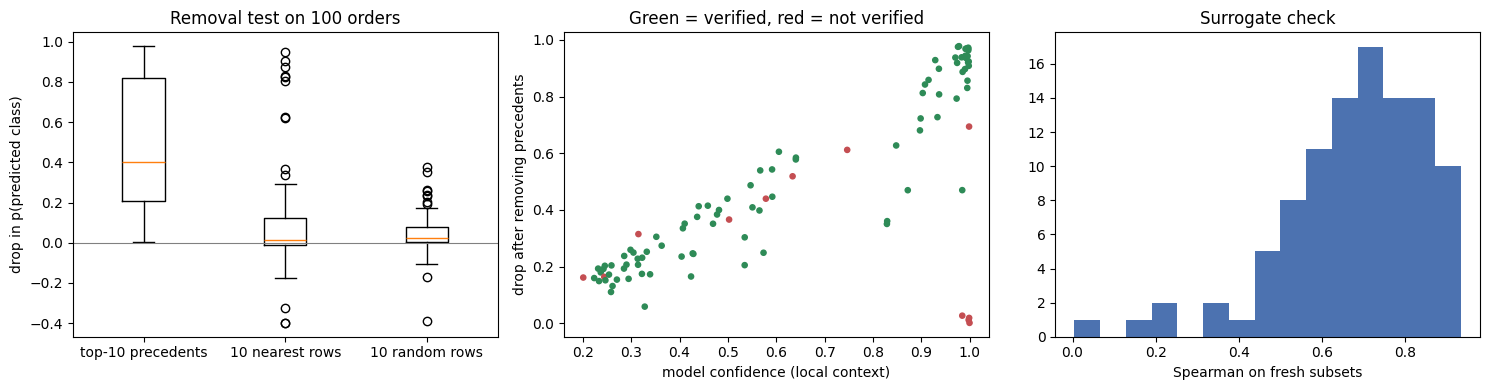

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].boxplot([res.drop_precedents, res.drop_nearest, res.drop_random_mean])
ax[0].set_xticklabels(["top-10 precedents", "10 nearest rows", "10 random rows"])
ax[0].axhline(0, color="grey", lw=0.8); ax[0].set_ylabel("drop in p(predicted class)")
ax[0].set_title(f"Removal test on {len(res)} orders")
ax[1].scatter(res.p_local, res.drop_precedents, s=14, c=res.verified.map({True: "#2E8B57", False: "#C44E52"}))
ax[1].set_xlabel("model confidence (local context)"); ax[1].set_ylabel("drop after removing precedents")
ax[1].set_title("Green = verified, red = not verified")
ax[2].hist(res.surrogate_spearman.dropna(), bins=15, color="#4C72B0")
ax[2].set_xlabel("Spearman on fresh subsets"); ax[2].set_title("Surrogate check")
plt.tight_layout(); plt.savefig("precedent_removal_test.png", dpi=160); plt.show()

## 7. Summary to paste back

How to read it:

- **Precedents vs random:** the mean drop for precedents should be far above random, with a small p-value.
- **Precedents vs nearest:** this is the real test. If removing the nearest rows hurts as much as removing the precedents, the influence scores add nothing beyond plain similarity.
- **Verified share:** the share of explanations that passed the removal test. Expect it to be low where confidence is above 0.99, because many near-identical rows back those predictions.
- **Local vs full:** shows how well the 60-row local context stands in for the full 2,000-row model.

In [10]:
summary = {"settings": {"target": TARGET, "n_context": int(len(X_ctx)), "K": K, "M": M, "TOP_K": TOP_K,
                        "N_RANDOM": N_RANDOM, "N_FRESH": N_FRESH, "N_EST": N_EST, "features": feat},
           "baseline": baseline, "overall": overall,
           "by_confidence": json.loads(by_conf.reset_index().astype({"confidence": str}).to_json(orient="records"))}
with open("precedent_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "settings": {
    "target": "CUSTOMERPAYMENTTERMS",
    "n_context": 2000,
    "K": 60,
    "M": 180,
    "TOP_K": 10,
    "N_RANDOM": 5,
    "N_FRESH": 20,
    "N_EST": 1,
    "features": [
      "SALESDOCUMENTTYPE",
      "SALESORGANIZATION",
      "DISTRIBUTIONCHANNEL",
      "BILLINGCOMPANYCODE",
      "TRANSACTIONCURRENCY",
      "CREATIONDATE",
      "CREATIONTIME",
      "SALESDOCUMENTITEMCATEGORY",
      "PRODUCT",
      "SOLDTOPARTY",
      "SHIPTOPARTY",
      "BILLTOPARTY",
      "PAYERPARTY",
      "ADDRESSID_SOLDTOPARTY",
      "ADDRESSID_BILLTOPARTY",
      "ADDRESSID_PAYERPARTY",
      "ADDRESSID_SHIPTOPARTY"
    ]
  },
  "baseline": {
    "n_test": 1000,
    "majority_class_share": 0.3125,
    "lightgbm_acc": 0.415,
    "tabpfn35_fast_acc": 0.644
  },
  "overall": {
    "orders_explained": 100,
    "mean_drop_precedents": 0.4821,
    "mean_drop_nearest": 0.092,
    "mean_drop_random": 0.0414,
    "median_drop_precedents": 0.3991,
    "verified_share": 0.88,
    "fli